In [1]:
#all imports
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

DATA_PATH = Path("../data/cleaned/cyberguard_text_dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (163924, 4)


In [2]:
#Recreating the robust template-aware split
import re
from sklearn.model_selection import StratifiedGroupKFold


def create_template_key(text):
    text = str(text).lower()

    text = re.sub(
        r'\b[\w\.-]+@[\w\.-]+\.\w+\b',
        ' EMAIL ',
        text
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'\b\d+\b',
        ' NUMBER ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["template_text"] = df["text"].apply(create_template_key)
df["template_group"] = df["template_text"].str[:500]

X = df["text"]
y = df["cyberguard_label"]
groups = df["template_group"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 131139
Testing : 32785


In [3]:
#TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=200000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF :", X_test_tfidf.shape)

Training TF-IDF: (131139, 200000)
Testing TF-IDF : (32785, 200000)


In [4]:
#creating the calibrated SVM
base_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",
    cv=3,
    n_jobs=-1
)

In [5]:
#trainig
print("Training calibrated SVM...")

calibrated_svm.fit(
    X_train_tfidf,
    y_train
)

print("Calibration completed.")

Training calibrated SVM...
Calibration completed.


In [6]:
#predictions and probability
calibrated_pred = calibrated_svm.predict(
    X_test_tfidf
)

calibrated_prob = calibrated_svm.predict_proba(
    X_test_tfidf
)[:, 1]

In [7]:
#Checking whether calibration affected classification performance
cal_accuracy = accuracy_score(
    y_test,
    calibrated_pred
)

cal_precision = precision_score(
    y_test,
    calibrated_pred
)

cal_recall = recall_score(
    y_test,
    calibrated_pred
)

cal_f1 = f1_score(
    y_test,
    calibrated_pred
)

print("===== Calibrated SVM =====")

print(f"Accuracy : {cal_accuracy:.6f}")
print(f"Precision: {cal_precision:.6f}")
print(f"Recall   : {cal_recall:.6f}")
print(f"F1 Score : {cal_f1:.6f}")

===== Calibrated SVM =====
Accuracy : 0.997834
Precision: 0.997021
Recall   : 0.998830
F1 Score : 0.997925


In [8]:
#classification report
print(
    classification_report(
        y_test,
        calibrated_pred,
        target_names=["Legitimate", "Suspicious"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     15695
  Suspicious       1.00      1.00      1.00     17090

    accuracy                           1.00     32785
   macro avg       1.00      1.00      1.00     32785
weighted avg       1.00      1.00      1.00     32785



In [9]:
#inspecting the probability distribution
probability_results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": calibrated_pred,
    "suspicious_probability": calibrated_prob
})

probability_results[
    "suspicious_probability"
].describe()

count    3.278500e+04
mean     5.229182e-01
std      4.880008e-01
min      1.068524e-11
25%      3.584353e-04
50%      9.359251e-01
75%      9.997376e-01
max      1.000000e+00
Name: suspicious_probability, dtype: float64

In [10]:
#high risk messages
probability_results.sort_values(
    "suspicious_probability",
    ascending=False
).head(10)[
    ["actual", "predicted", "suspicious_probability", "text"]
]

,actual,predicted,suspicious_probability,text
19188,1,1,1.0,special offers downloadable software paliourg ...
18990,1,1,1.0,fda approved medications sun 06 feb 2005 08 45...
20045,1,1,1.0,phentermine xenical viagra offer absolute lowe...
12432,1,1,1.0,"phentermine , xenical , viagra we offer the ab..."
15427,1,1,1.0,Phentermine & Viagra Here We are the largest U...
13260,1,1,1.0,. - : cheao online pharmacy + ' * ' ` c + he +...
18957,1,1,1.0,pharmacist confirmation cialis 7304001 mon 14 ...
16402,1,1,1.0,best choice rx free online prescriptions fedex...
8674,1,1,1.0,"popularity pills , cheap ! ! ! viagra , cialis..."
16317,1,1,1.0,paliourg learning life enlarge member zenexten...


In [11]:
#low rish messages
probability_results.sort_values(
    "suspicious_probability",
    ascending=True
).head(10)[
    ["actual", "predicted", "suspicious_probability", "text"]
]

,actual,predicted,suspicious_probability,text
19738,0,0,1.068524e-11,reply sally give deep thought weekend meantime...
9145,0,0,6.280679e-11,re : corporate allocation from enron research ...
17269,0,0,6.356974e-11,india model stinson vince please see wade comm...
9709,0,0,6.356974e-11,"re : india model stinson and vince , please se..."
17659,0,0,6.463751e-11,americas 3 q presentation thanks really apprec...
16683,0,0,6.806944e-11,latest last sorry found something else p 1 foo...
9775,0,0,1.308099e-10,"enron in india hi vince , i was not aware of t..."
12132,0,0,1.828333e-10,august end of month close - a summary debrief ...
12316,0,0,1.991811e-10,re : enpower i have not personally talked to j...
16721,0,0,2.006177e-10,london status report research weather effort v...


In [12]:
#creating probability buckets
probability_results["risk_bucket"] = pd.cut(
    probability_results["suspicious_probability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%",
        ],
    include_lowest=True
)

print(
    probability_results["risk_bucket"].value_counts(
        sort=False
    )
)

risk_bucket
0-20%      15254
20-40%       382
40-60%        52
60-80%       299
80-100%    16798
Name: count, dtype: int64


In [13]:
#checking the calibration quality
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10,
    strategy="uniform"
)

calibration_df = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "actual_suspicious_rate": prob_true
})

calibration_df

,mean_predicted_probability,actual_suspicious_rate
0,0.004939,0.000134
1,0.143776,0.006369
2,0.250062,0.013333
3,0.331561,0.031847
4,0.455597,0.285714
5,0.537767,0.291667
6,0.671659,0.933884
7,0.749522,0.977528
8,0.855289,0.965217
9,0.994662,0.999155


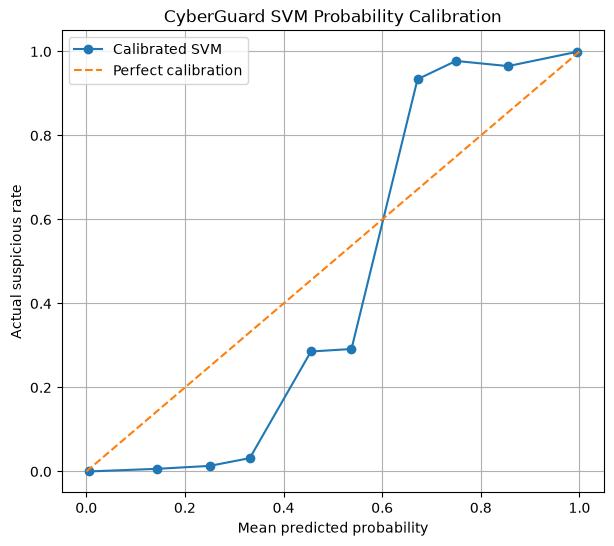

In [15]:
#plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual suspicious rate")
plt.title("CyberGuard SVM Probability Calibration")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
#saving the calibrated model
import joblib

MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../results")

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

joblib.dump(
    calibrated_svm,
    MODEL_DIR / "cyberguard_calibrated_svm.pkl"
)

joblib.dump(
    tfidf,
    MODEL_DIR / "cyberguard_tfidf.pkl"
)

calibration_df.to_csv(
    RESULTS_DIR / "svm_calibration_results.csv",
    index=False
)

print("Calibrated CyberGuard model saved.")

Calibrated CyberGuard model saved.
